In [1]:
%cd /home/maia-user/NeuroCBIR/
!ls

/home/maia-user/NeuroCBIR
 cbir			     monai_test.ipynb
 CBIR.ipynb		     preprocessing
 CBIR_wholeBrain.ipynb	     README.md
 CBIR_wholeBrain_SVF.ipynb   reports
 compute_SVF.ipynb	     seg_preparation.ipynb
 data			     subcortical_AE_training.ipynb
 global_AE_training.ipynb   'subcortical_SVF_training .ipynb'
 global_SVF_training.ipynb   training
 model			     utils


/usr/local/lib/python3.10/dist-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [8]:
# pip install monai


In [3]:
# pip uninstall monai -y

In [4]:
# !pip uninstall -y monai-weekly

## Data preparation

In [5]:

# import argparse
# import json
# import os
# import torch
# from monai.config import print_config
# from monai.utils import set_determinism

# from utils import define_instance

# parser = argparse.ArgumentParser(description="PyTorch Latent Diffusion Model Inference")
# parser.add_argument(
#     "-e",
#     "--environment-file",
#     default="./data/config/environment.json",
#     help="environment json file that stores environment path",
# )
# parser.add_argument(
#     "-c",
#     "--config-file",
#     default="./data/config/config_train_32g.json",
#     help="config json file that stores hyper-parameters",
# )
# parser.add_argument(
#     "-n",
#     "--num",
#     type=int,
#     default=1,
#     help="number of generated images",
# )
# args = parser.parse_args()

# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# print_config()
# torch.backends.cudnn.benchmark = True
# torch.set_num_threads(4)

# env_dict = json.load(open(args.environment_file, "r"))
# config_dict = json.load(open(args.config_file, "r"))

# for k, v in env_dict.items():
#     setattr(args, k, v)
# for k, v in config_dict.items():
#     setattr(args, k, v)

# set_determinism(42)

# # load trained networks
# autoencoder = define_instance(args, "autoencoder_def").to(device)
# trained_g_path = os.path.join(args.model_dir, "autoencoder.pt")
# autoencoder.load_state_dict(torch.load(trained_g_path, weights_only=True))

In [6]:
# import torch
# from model.autoencoder import Conv3DSparseAutoencoder
# from torchsummary import summary

# # Device setup
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# # Input size: [160, 176, 208]
# input_size = [64, 80, 48]

# # Initialize model and move it to the correct device
# autoencoder = Conv3DSparseAutoencoder().to(device)

# # Run summary — torchsummary will match the device of the model
# _=summary(autoencoder, (1, *input_size))

In [28]:
import torch
import os
from monai.networks.nets.autoencoderkl import AutoencoderKL

from monai.utils import set_determinism
set_determinism(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# load trained networks
# autoencoder = define_instance(args, "autoencoder_def").to(device)
autoencoder = AutoencoderKL(
    spatial_dims=3,
    in_channels=1,
    out_channels=1,
    channels=(64, 128, 256),
    latent_channels=8,
    num_res_blocks=2,
    norm_num_groups=32,
    norm_eps=1e-06,
    attention_levels=(False, False, False),
    with_encoder_nonlocal_attn=False,
    with_decoder_nonlocal_attn=False,
    include_fc=False

)
autoencoder.to(device)




trained_g_path = os.path.join("./data/pretrained_models/", "model_autoencoder.pt")
# autoencoder.load_state_dict(torch.load(trained_g_path, weights_only=True))

In [31]:
import torch
import re

# Load the saved state_dict
ckpt_path = "./data/pretrained_models/model_autoencoder.pt"
state_dict = torch.load(ckpt_path)

# Remap keys from conv.conv.* → postconv.conv.*
new_state_dict = {}
for key in state_dict:
    new_key = re.sub(r"(decoder\.blocks\.(3|6))\.conv\.conv\.", r"\1.postconv.conv.", key)
    new_state_dict[new_key] = state_dict[key]

# Load into model
autoencoder.load_state_dict(new_state_dict, strict=True)


<All keys matched successfully>

In [32]:
autoencoder.to(device)


AutoencoderKL(
  (encoder): Encoder(
    (blocks): ModuleList(
      (0): Convolution(
        (conv): Conv3d(1, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
      )
      (1-2): 2 x AEKLResBlock(
        (norm1): GroupNorm(32, 64, eps=1e-06, affine=True)
        (conv1): Convolution(
          (conv): Conv3d(64, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
        )
        (norm2): GroupNorm(32, 64, eps=1e-06, affine=True)
        (conv2): Convolution(
          (conv): Conv3d(64, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
        )
        (nin_shortcut): Identity()
      )
      (3): AEKLDownsample(
        (pad): AsymmetricPad()
        (conv): Convolution(
          (conv): Conv3d(64, 64, kernel_size=(3, 3, 3), stride=(2, 2, 2))
        )
      )
      (4): AEKLResBlock(
        (norm1): GroupNorm(32, 64, eps=1e-06, affine=True)
        (conv1): Convolution(
          (conv): Conv3d(64, 128, kernel_size=(3, 3, 3), stride=

In [12]:
import sys
print(sys.executable)

/usr/bin/python3


In [13]:
import torch
import torch.nn as nn
import os
import pandas as pd
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader
from IPython.display import clear_output

seed = 42

In [17]:
from preprocessing.load_dataset import list_files_with_extension, BrainMRIDataset, get_label

# Loading MRI  paths
dataset_path = r"/home/maia-user/Dataset/OASIS3_NPY_UINT/"
file_paths, file_names = list_files_with_extension(dataset_path, extension=".npy")
raw_image_paths = np.array([os.path.join(dataset_path, file_path, file_name) for file_path, file_name in zip(file_paths, file_names)])
raw_image_ids = np.array([file_path.split('.')[0] for file_path in file_names])

# Load file with labels
labels_path = r"/home/maia-user/Dataset/OASIS3/OASIS3_UDSb4_cdr.xlsx"
labels_df = pd.read_excel(labels_path, sheet_name= 'Labels')

# Some recordings might be removed, i.e. nan labels
raw_labels = np.array([get_label(image_id, labels_df) for image_id in raw_image_ids]).astype('float32')
raw_ages = np.array([get_label(image_id, labels_df, column='age_at_visit') for image_id in raw_image_ids]).astype('float32')
raw_ids = np.array([get_label(image_id, labels_df, column='OASISID') for image_id in raw_image_ids])

# Filtering out undesired cases
labels = raw_labels[~np.isnan(raw_labels)]
image_paths = raw_image_paths[~np.isnan(raw_labels)]
ages = raw_ages[~np.isnan(raw_labels)]
ids = raw_ids[~np.isnan(raw_labels)]

print(raw_labels.shape, labels.shape)

(2681,) (2680,)


In [19]:
from preprocessing.split_dataset import stratified_patient_split

# Longitudinal splitting dataset into training and testing sets
train_set, val_set, test_set = stratified_patient_split(image_paths=image_paths, labels=labels, ages=ages, ids=ids)

# Print dataset sizes
print(f"Training samples: {len(train_set['image_paths'])} - IR: {np.sum(train_set['labels'])/len(train_set['image_paths']):.2f}")
print(f"Validation samples: {len(val_set['image_paths'])} - IR: {np.sum(val_set['labels'])/len(val_set['image_paths']):.2f}")
print(f"Testing samples: {len(test_set['image_paths'])} - IR: {np.sum(test_set['labels'])/len(val_set['image_paths']):.2f}")

Training samples: 1852 - IR: 0.20
Validation samples: 372 - IR: 0.21
Testing samples: 456 - IR: 0.26


In [20]:
from preprocessing.load_dataset import StratifiedBatchSampler
import torchio as tio

batch_size = 24  # Make sure this is even!

augmentation_transforms = tio.Compose([
                                        # tio.RandomAffine(
                                        #     scales=(0.9, 1.05),        # Random scaling
                                        #     degrees=5,               # Random rotation in degrees
                                        #     translation=5            # Random translation in mm
                                        # ),
                                        tio.RandomNoise(mean=0.0, std=0.02),
                                        # tio.RandomFlip(axes=('LR',)),  # Random left-right flip
                                    ])

# Preparing the dataset to feed the network
train_dataset = BrainMRIDataset(train_set['image_paths'], train_set['ages'], train_set['labels'], 
                                transform=None, transform_age=3, cache=False, sparse_path=None)
train_sampler = StratifiedBatchSampler(train_dataset, batch_size)
train_loader = DataLoader(train_dataset, batch_sampler=train_sampler, pin_memory=True, num_workers=1)

val_dataset = BrainMRIDataset(val_set['image_paths'], val_set['ages'], val_set['labels'], cache=False, sparse_path=None)
val_sampler = StratifiedBatchSampler(val_dataset, batch_size)
val_loader = DataLoader(val_dataset, batch_sampler=val_sampler, num_workers=1)

test_dataset = BrainMRIDataset(test_set['image_paths'], test_set['ages'], test_set['labels'], cache=False, sparse_path=None)
test_sampler = StratifiedBatchSampler(test_dataset, batch_size)
test_loader = DataLoader(test_dataset, batch_sampler=test_sampler, num_workers=1)

In [21]:
dataset = BrainMRIDataset(image_paths, ages, labels,
                          transform=None, transform_age=3, cache=False, sparse_path=None)

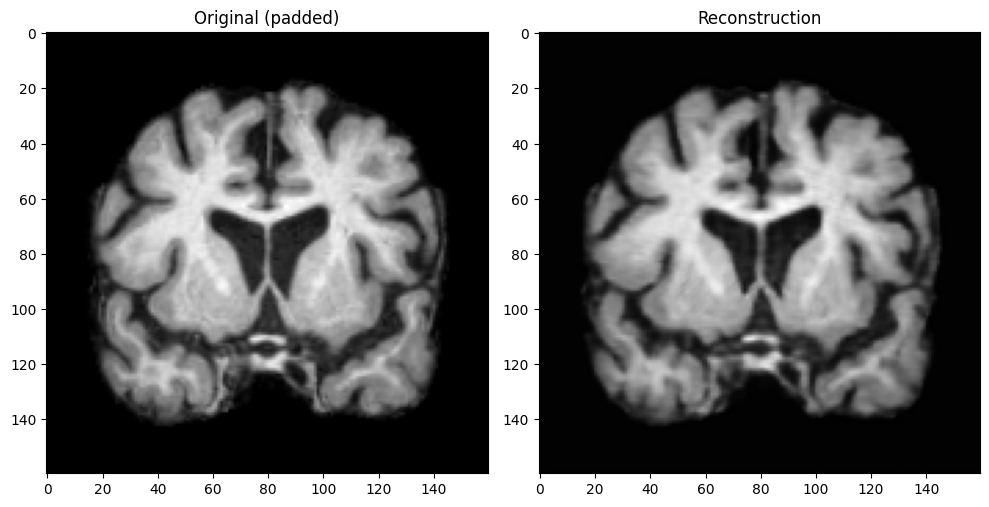

In [63]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# Load sample
sample = dataset[566]
img = sample['input']  # shape: [1, 176, 208, 160]

# Desired shape: [1, 160, 224, 160]
target_shape = [1, 160, 224, 160]
current_shape = list(img.shape)

# Calculate padding: (left, right, top, bottom, front, back)
pad_d = (0, target_shape[3] - current_shape[3])  # depth (no change)
pad_h = (0, target_shape[2] - current_shape[2])  # height
pad_w = (0, target_shape[1] - current_shape[1])  # width

# Flatten padding list: reverse order for F.pad → (D, H, W)
padding = pad_d + pad_h + pad_w  # [depth, height, width]

# Pad image
padded_img = F.pad(img, padding).unsqueeze(0).to(device)

# Inference through autoencoder
autoencoder.eval()
with torch.no_grad():
    reconstruction, z_mu, z_sigma = autoencoder(padded_img)  # add batch dim
    reconstruction = reconstruction.squeeze(0)  # remove batch dim

# Visualize middle slice of the original and reconstructed images
def show_slices(tensor1, tensor2, axis=0):
    fig, axs = plt.subplots(1, 2, figsize=(10, 5))
    
    idx = tensor1.shape[axis] // 2
    slice1 = tensor1[0].select(dim=axis, index=idx).cpu()
    slice2 = tensor2[0].select(dim=axis, index=idx).cpu()

    axs[0].imshow(slice1, cmap="gray")
    axs[0].set_title("Original (padded)")

    axs[1].imshow(slice2, cmap="gray")
    axs[1].set_title("Reconstruction")

    plt.tight_layout()
    plt.show()

# Show middle slice along depth axis (0)
original_img = padded_img.squeeze(0)
show_slices(original_img, reconstruction, axis=1)


In [ ]:
import torch

# Ensure the code runs on the same device
device = z_mu.device  

# Sample from a standard normal distribution
epsilon = torch.randn_like(z_sigma).to(device)

# Reparameterization trick
z = z_mu + z_sigma * epsilon


In [69]:
np.prod(z_mu.shape) / np.prod(original_img.shape)

0.125

In [ ]:
import torch
import numpy as np
from tqdm import tqdm

def extract_whole_image_features(autoencoder, dataset, device="cuda", subject_ids=None, record_ids=None, dementia_subcortical_indices=None):
    if not dementia_subcortical_indices:
        dementia_subcortical_indices = {
                    "Hippocampus (lh)": 17, "Hippocampus (rh)": 53, "Amygdala (lh)": 18, "Amygdala (rh)": 54, "Thalamus (lh)": 10,
                    "Thalamus (rh)": 49, "Caudate (lh)": 11, "Caudate (rh)": 50, "Putamen (lh)": 12, "Putamen (rh)": 51,
                }

    autoencoder.to(device)
    autoencoder.eval()
    data = []

    for idx in tqdm(range(len(dataset)), desc="Extracting features"):
        # for ss_idx, (key, _) in enumerate(dementia_subcortical_indices.items()):
        key="whole_brain"
        if record_ids is not None:
            record_id = record_ids[idx]

        if subject_ids is not None:
            subject_id = subject_ids[idx]
            
        sample = dataset[idx]
        img = sample["input"].unsqueeze(0).to(device, dtype=torch.float32)
        
        with torch.no_grad():
            z, _ = autoencoder(img)
        
        data.append({
            "subject_id": subject_id,
            "record_id": record_id,
            "subc_str": key,
            "label": sample["label"].item(),
            "age": sample["age"].item(),
            "features": z.view(-1).cpu().numpy(),
        })
        
    return data

record_ids = [im_path.split("/")[-1].split(".")[0] for im_path in image_paths]

t = -1
dataset = BrainMRIDataset(image_paths[0:t], ages[0:t], labels[0:t],
                          transform=None, transform_age=None, cache=False, sparse_path=None)
dataset_feats = extract_whole_image_features(autoencoder, dataset, device="cpu", record_ids=record_ids[0:t], subject_ids=ids[0:t])

np.save(f"./data/dataset_feats_{report.timestamp}.npy", dataset_feats)

tensor(0.1414, device='cuda:0')

In [50]:
reconstruction.shape

torch.Size([1, 160, 224, 160])

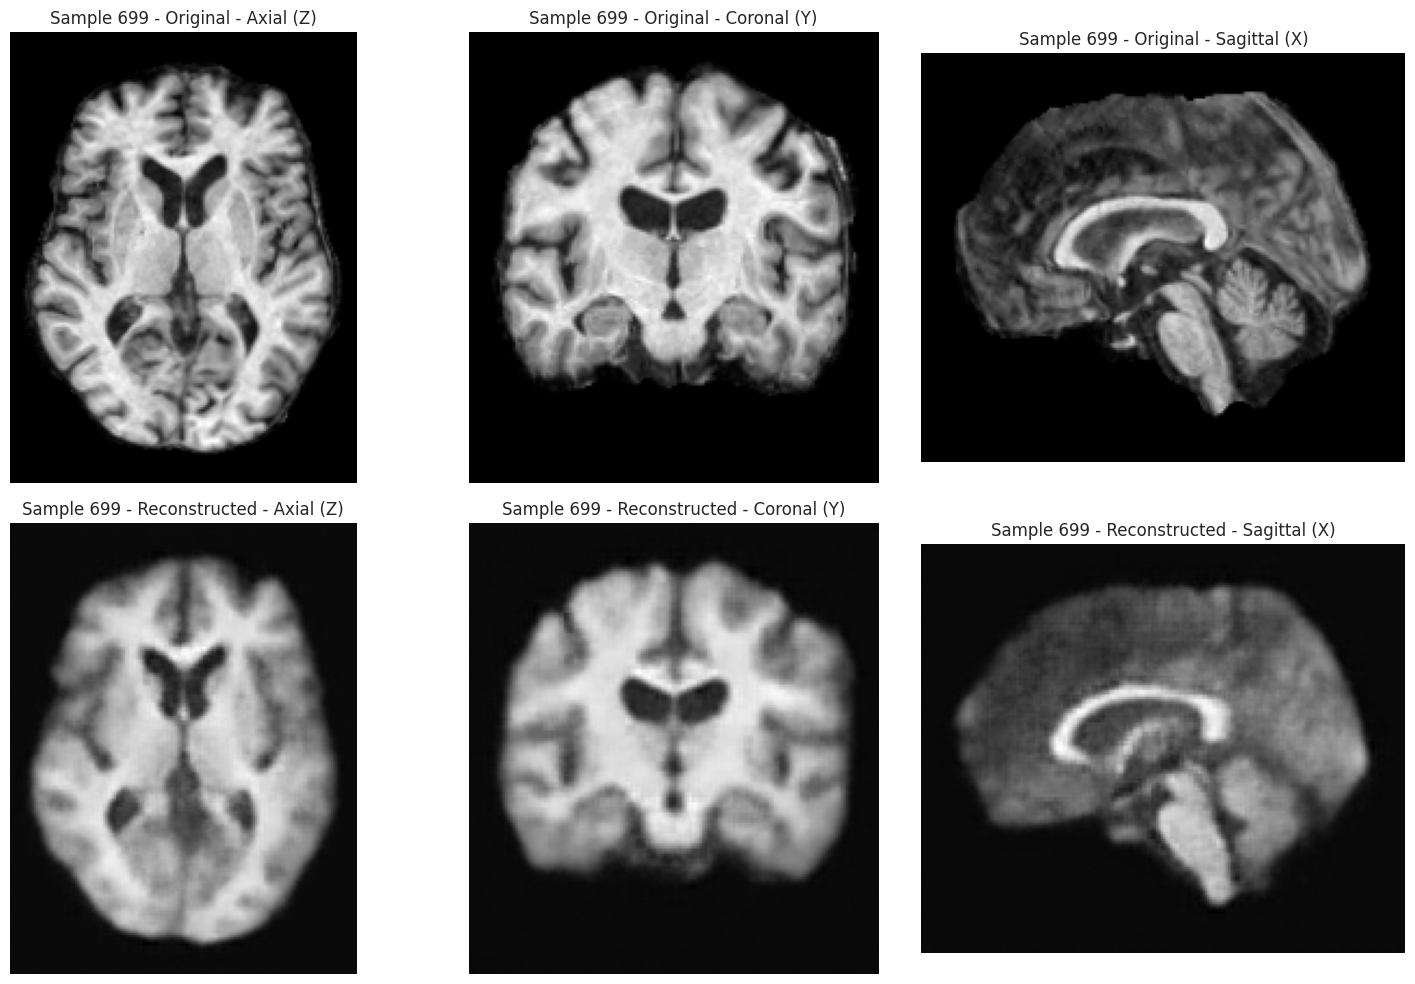

In [44]:
from utils.visualization import visualize_autoencoder_reconstruction

sample_1 = dataset[699]
visualize_autoencoder_reconstruction(autoencoder, sample_1, device, substructure_index=0, title_prefix="Sample 699 - ")